<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 0.8193 acc 0.629 | val loss 0.5846 acc 0.766 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.5863 acc 0.751 | val loss 0.5215 acc 0.808 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.5044 acc 0.784 | val loss 0.5740 acc 0.770


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.4567 acc 0.802 | val loss 0.5029 acc 0.828 *


...

[DenseNet-121] Epoch  18/100 | LR: 3.44e-05 | train loss 0.1053 acc 0.949 | val loss 0.3848 acc 0.883


[DenseNet-121] Epoch  19/100 | LR: 3.44e-05 | train loss 0.0977 acc 0.954 | val loss 0.3877 acc 0.877


[DenseNet-121] Epoch  20/100 | LR: 3.44e-05 | train loss 0.0875 acc 0.963 | val loss 0.3873 acc 0.869


[DenseNet-121] Epoch  21/100 | LR: 3.44e-05 | train loss 0.0840 acc 0.963 | val loss 0.3989 acc 0.871


[DenseNet-121] Epoch  22/100 | LR: 3.44e-06 | train loss 0.0872 acc 0.963 | val loss 0.3955 acc 0.883

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 22.

[DenseNet-121] Restored best checkpoint (val loss = 0.3742)


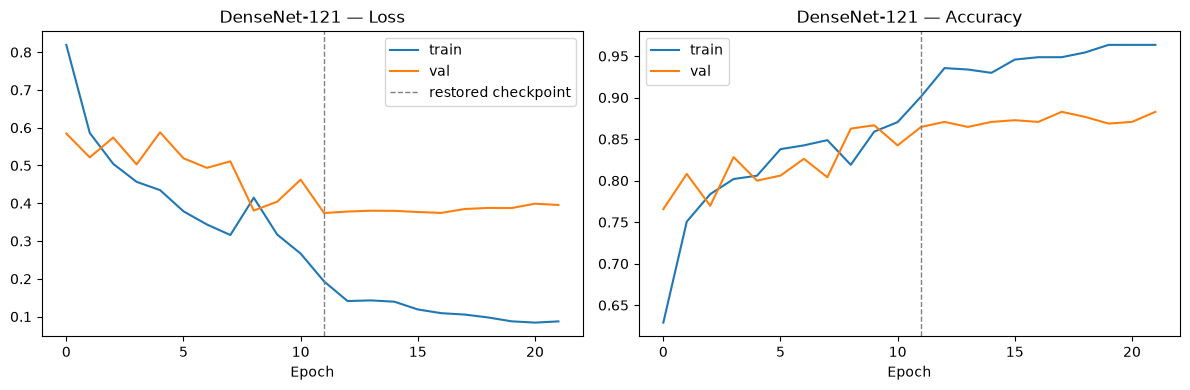

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.882


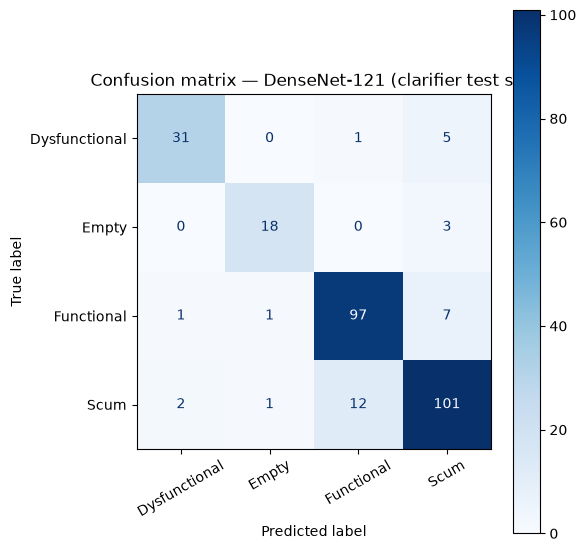

               precision    recall  f1-score   support

Dysfunctional      0.912     0.838     0.873        37
        Empty      0.900     0.857     0.878        21
   Functional      0.882     0.915     0.898       106
         Scum      0.871     0.871     0.871       116

     accuracy                          0.882       280
    macro avg      0.891     0.870     0.880       280
 weighted avg      0.883     0.882     0.882       280



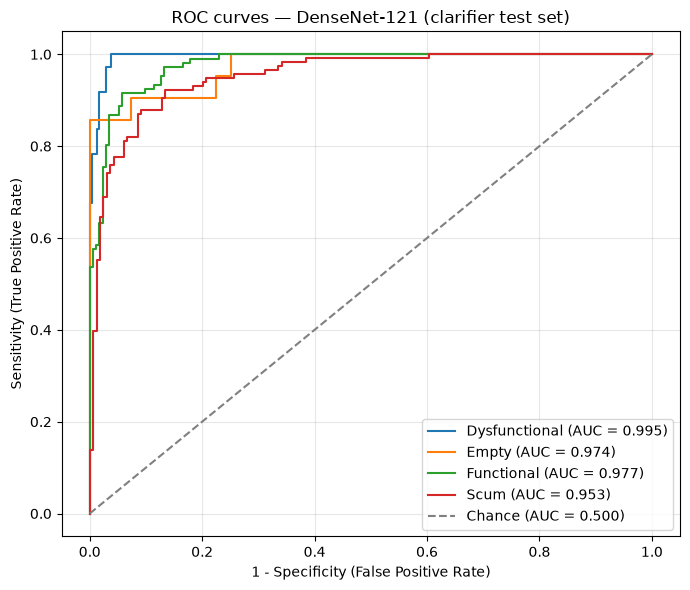

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.995
  Empty          : 0.974
  Functional     : 0.977
  Scum           : 0.953

Mean AUC (over 4/4 classes with test examples): 0.975


(np.float64(0.8821428571428571),
 {'Dysfunctional': 0.994994994994995,
  'Empty': 0.9738922596065454,
  'Functional': 0.9774994578182608,
  'Scum': 0.9529541631623213})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_aug/results_clarifier_densenet121_stratified.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
